# Text Emotion Recognition — Experiments

Step-by-step fine-tuning of text embeddings for emotion classification using the MELD dataset.
We compare model performance across two input strategies: isolated single utterances vs. context-linked utterances.

| Model | Input Type | Search Space (Hyperparameters) | Epochs |
|---|---|---|---|
| **RoBERTa-base** | Single Utterance (No Context) | Learning Rate `[1e-5, 5e-5]`, Batch Size, Weight Decay | 3-5 |
| **RoBERTa-base** | Linked Utterance (With Context) | Learning Rate `[1e-5, 5e-5]`, Batch Size, Weight Decay | 3-5 |

Run cells top-to-bottom. Models are evaluated using the **weighted F1 score** to account for the heavy class imbalance (majority 'Neutral').

In [6]:
import sys, json
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import os

# -------------------------------------------------------
# Setup Paths (Aligning with project structure)
# -------------------------------------------------------
SRC = Path("../src").resolve()
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

DATA_ROOT = Path("../data/raw")
MODELS_DIR = Path("../data/models") 

# Ensure the models directory exists so saving doesn't crash later
MODELS_DIR.mkdir(parents=True, exist_ok=True)

EMOTION_ORDER = ["neutral", "joy", "sadness", "anger",
    "surprise_positive", "surprise_negative", "disgust", "fear"]

EMOTION_COLORS = {
    "neutral": "#888780", "joy": "#639922", "sadness":  "#378ADD",
    "anger": "#E24B4A", "surprise_positive": "#F4C242", "surprise_negative": "#C97A1E", 
    "disgust":  "#D4537E", "fear": "#7F77DD"}

# -------------------------------------------------------
# Plotting Configuration
# -------------------------------------------------------
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120

# -------------------------------------------------------
# Local Hardware Check
# -------------------------------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Text Setup done.\n" + "-"*30)
print(f"Hardware computing device: {device}")

# If training locally on a CPU, training will be highly bottlenecked
if device.type == 'cpu':
    print("⚠️ WARNING: No GPU detected. Training RoBERTa locally on a CPU will take a very long time.")
    print("💡 Tip: If it is too slow, swap 'roberta-base' for 'distilroberta-base' in your training code.")
else:
    print(f"✅ GPU detected: {torch.cuda.get_device_name(0)}")

print("-" * 30)
print(f"Reading data from: {DATA_ROOT}")
print(f"Saving model weights to: {MODELS_DIR}")

Text Setup done.
------------------------------
Hardware computing device: cuda
✅ GPU detected: Tesla T4
------------------------------
Reading data from: ../data/raw
Saving model weights to: ../data/models


In [7]:
#data processing 
from sklearn.utils.class_weight import compute_class_weight

# 1. Configuration
PROCESSED_ROOT = Path("../data/processed")
PROCESSED_ROOT.mkdir(parents=True, exist_ok=True) 

def process_meld_data(filepath):
    df = pd.read_csv(filepath)
    df.columns = [c.strip() for c in df.columns]
    
    # 2. The Context Logic using the NEW column names
    df['prev_text'] = df.groupby('dialogue_id')['text'].shift(1)
    df['prev_text'] = df['prev_text'].fillna("")
    
    # Create the two versions for your report
    df['text_no_context'] = df['text']
    df['text_with_context'] = df.apply(
        lambda x: f"{x['prev_text']} </s> {x['text']}" if x['prev_text'] != "" 
        else x['text'], axis=1)
    
    # Use the label_idx provided by your team's new structure
    df['label'] = df['label_idx']
    
    return df[['text_no_context', 'text_with_context', 'label', 'emotion', 'dialogue_id', 'utterance_id']]

# 3. Execution (Update these filenames to whatever your team renamed them to)
print("Processing datasets...")
train_df = process_meld_data(DATA_ROOT / 'manifest_train.csv')
val_df   = process_meld_data(DATA_ROOT / 'manifest_dev.csv')  
test_df  = process_meld_data(DATA_ROOT / 'manifest_test.csv')  

# 4. Save Processed Data
print("Saving processed data to ../data/processed/ ...")
train_df.to_csv(PROCESSED_ROOT / 'train_processed.csv', index=False)
val_df.to_csv(PROCESSED_ROOT / 'val_processed.csv', index=False)
test_df.to_csv(PROCESSED_ROOT / 'test_processed.csv', index=False)

# 5. Calculate Weighted Loss Values for the 8 classes
labels = train_df['label'].values
class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(labels), y=labels)

print("\nClass Weights calculated successfully:")
# Dynamically print the weights based on the unique emotions in the train set
unique_emotions = train_df.drop_duplicates('label').sort_values('label')
for _, row in unique_emotions.iterrows():
    print(f"{row['emotion']} (Index {row['label']}): {class_weights[row['label']]:.4f}")

Processing datasets...
Saving processed data to ../data/processed/ ...



Class Weights calculated successfully:
neutral (Index 0): 0.2651
joy (Index 1): 0.7163
anger (Index 2): 1.1258
sadness (Index 3): 1.8280
disgust (Index 4): 4.6070
fear (Index 5): 4.6586
surprise_positive (Index 6): 2.1125
surprise_negative (Index 7): 2.0334


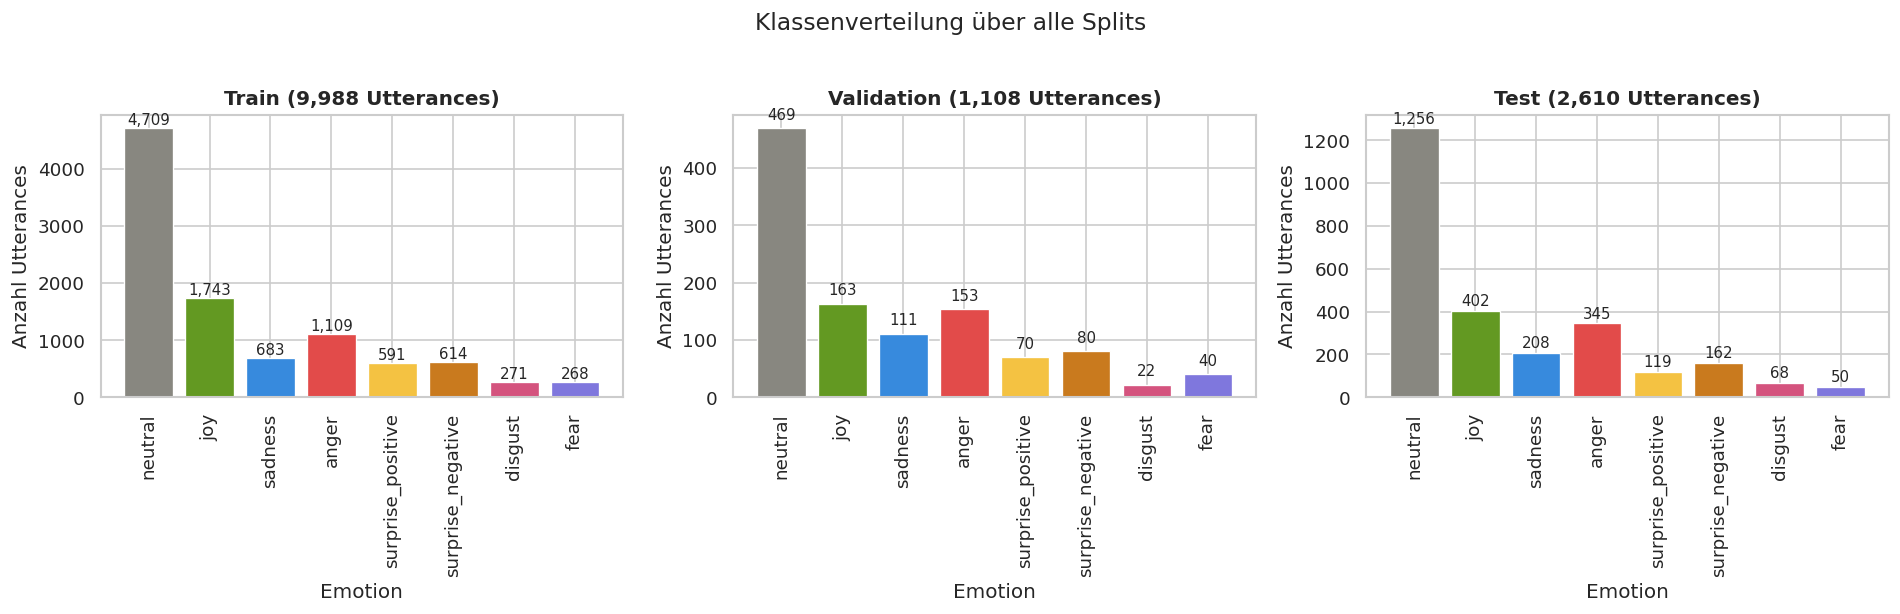

Plot gespeichert.


In [4]:
#viz data balance with new data structure including emotion

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=False)

for ax, (df, title) in zip(axes, [
    (train_df, "Train"), (val_df, "Validation"), (test_df, "Test")
]):
    counts = df["emotion"].value_counts().reindex(EMOTION_ORDER).fillna(0)
    colors = [EMOTION_COLORS[e] for e in counts.index]
    bars = ax.bar(counts.index, counts.values, color=colors, edgecolor="white", linewidth=0.8)
    ax.set_title(f"{title} ({len(df):,} Utterances)", fontweight="bold")
    ax.set_xlabel("Emotion")
    ax.set_ylabel("Anzahl Utterances")
    ax.tick_params(axis="x", rotation=90)
    # Werte über den Balken
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 10, f"{int(h):,}",
                ha="center", va="bottom", fontsize=9)

plt.suptitle("Klassenverteilung über alle Splits", fontsize=14, y=1.02)
plt.tight_layout()
os.makedirs("../outputs/plots", exist_ok=True)
plt.savefig("../outputs/plots/class_distribution.png", bbox_inches="tight")
plt.show()
print("Plot gespeichert.")

In [11]:
from transformers import RobertaTokenizer, RobertaForSequenceClassification, TrainingArguments, Trainer
from sklearn.metrics import f1_score, accuracy_score
import torch
from torch import nn

# 1. Load the Tokenizer
model_name = 'roberta-base'
tokenizer = RobertaTokenizer.from_pretrained(model_name)

# 2. Define the PyTorch Dataset
class MELDTextDataset(torch.utils.data.Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts = texts.tolist()
        self.labels = labels.tolist()
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]

        encoding = self.tokenizer(
            text,
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

# 3. Define the Evaluation Metric (Macro F1)
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    
    # Calculate both so you have full visibility for your report
    macro_f1 = f1_score(labels, preds, average='macro')
    weighted_f1 = f1_score(labels, preds, average='weighted')
    acc = accuracy_score(labels, preds)
    
    return {
        'macro_f1': macro_f1,          # The optimizer will look at this!
        'weighted_f1': weighted_f1,    # Kept for reference
        'accuracy': acc
    }

In [12]:
# Convert the class weights into a PyTorch tensor and move to GPU
weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")
        
        loss_fct = nn.CrossEntropyLoss(weight=weights_tensor)
        # Using 8 classes here based on the split surprise emotion
        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))
        
        return (loss, outputs) if return_outputs else loss

In [14]:
def train_and_evaluate(text_column_name, run_name):
    print(f"\n--- Starting Run: {run_name} using column '{text_column_name}' ---")
    
    # 1. Create Datasets
    train_dataset = MELDTextDataset(train_df[text_column_name], train_df['label'], tokenizer)
    val_dataset = MELDTextDataset(val_df[text_column_name], val_df['label'], tokenizer)
    
    # 2. Initialize a fresh model
    model = RobertaForSequenceClassification.from_pretrained(model_name, num_labels=8)
    model.to(device)
    
    # 3. Define Training Arguments
    run_output_dir = MODELS_DIR / run_name
    training_args = TrainingArguments(
        output_dir=str(run_output_dir),
        num_train_epochs=4,              
        per_device_train_batch_size=16,  
        per_device_eval_batch_size=32,
        learning_rate=2e-5,              
        weight_decay=0.01,
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,     
        metric_for_best_model="macro_f1", # <--- CHANGED: Now optimizing for Macro F1
    )
    
    # 4. Initialize our Custom Trainer
    trainer = WeightedTrainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        compute_metrics=compute_metrics
    )
    
    # 5. Train!
    print("Training started...")
    trainer.train()
    
    # 6. Final Evaluation
    print("\nEvaluating best model on Val Set...")
    eval_results = trainer.evaluate()
    
    # Updated print statement to show the new primary metric
    print(f"Final Val Macro F1: {eval_results['eval_macro_f1']:.4f}")
    print(f"(Reference) Val Weighted F1: {eval_results['eval_weighted_f1']:.4f}")
    
    # Save the final best model
    trainer.save_model(str(run_output_dir / "best_model"))
    print(f"Model saved to {run_output_dir / 'best_model'}")

# ==========================================
# UNCOMMENT TO RUN ON DESKTOP
# ==========================================
# Run 1: Baseline (No Context)
#train_and_evaluate(text_column_name='text_no_context', run_name='roberta_baseline')

# Run 2: With Context
#train_and_evaluate(text_column_name='text_with_context', run_name='roberta_context')

In [13]:
#hyperparameter tuning with optuna
import optuna
import gc
import torch

def objective(trial):
    # 1. Memory Management (CRITICAL FOR CLOUD GPUs)
    # This wipes the GPU memory clean before starting a new trial so it doesn't crash
    torch.cuda.empty_cache()
    gc.collect()
    
    print(f"\n--- Starting Optuna Trial {trial.number} ---")
    
    # 2. Let Optuna guess the best hyperparameters
    learning_rate = trial.suggest_float("learning_rate", 1e-6, 5e-5, log=True)
    batch_size = trial.suggest_categorical("per_device_train_batch_size", [8, 16]) 
    num_epochs = trial.suggest_int("num_train_epochs", 3, 5)
    weight_decay = trial.suggest_float("weight_decay", 0.0, 0.1)
    
    # 3. CONNECT YOUR DATA (The winning context column!)
    train_dataset = MELDTextDataset(train_df['text_with_context'], train_df['label'], tokenizer)
    dev_dataset = MELDTextDataset(val_df['text_with_context'], val_df['label'], tokenizer)
    
    # 4. Initialize a FRESH model for this trial (8 output labels)
    # If you don't do this inside the function, it cheats by using the previous trial's memory
    model = RobertaForSequenceClassification.from_pretrained(model_name, num_labels=8)
    model.to(device)
    
    # 5. Set up Training Arguments with Optuna's guesses
    run_output_dir = MODELS_DIR / f"optuna_trial_{trial.number}"
    training_args = TrainingArguments(
        output_dir=str(run_output_dir),
        num_train_epochs=num_epochs,
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=32, 
        learning_rate=learning_rate,
        weight_decay=0.01,
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="macro_f1",
        disable_tqdm=True 
    )
    
    # 6. Initialize our custom WeightedTrainer
    trainer = WeightedTrainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=dev_dataset,
        compute_metrics=compute_metrics
    )
    
    # 7. Train and evaluate this specific combination
    trainer.train()
    eval_results = trainer.evaluate()
    
    # 8. Report the Macro F1 score back to Optuna
    # Optuna uses this score to make a smarter guess in the next trial
    return eval_results['eval_macro_f1']

# ==========================================
# EXECUTE THE OPTIMIZATION
# ==========================================
print("Starting Hyperparameter Optimization...")

# We want to MAXIMIZE the Macro F1 score
study = optuna.create_study(direction="maximize")

# Run 10 trials (This might take 1-2 hours depending on your cloud GPU)
study.optimize(objective, n_trials=10)

print("\n==========================================")
print("OPTIMIZATION COMPLETE")
print("Best Macro F1 Score:", study.best_value)
print("Best Hyperparameters:", study.best_params)
print("==========================================")


[I 2026-05-18 17:17:51,069] A new study created in memory with name: no-name-8161c77a-0ad7-48fa-b7e8-bc1ffa47aaf1


Starting Hyperparameter Optimization...

--- Starting Optuna Trial 0 ---


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.dense.bias         | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.bias      | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


{'loss': '2.083', 'grad_norm': '4.477', 'learning_rate': '1.318e-06', 'epoch': '0.8'}
{'eval_loss': '2.041', 'eval_macro_f1': '0.1815', 'eval_weighted_f1': '0.318', 'eval_accuracy': '0.315', 'eval_runtime': '7.402', 'eval_samples_per_second': '149.7', 'eval_steps_per_second': '4.729', 'epoch': '1'}


...

{'loss': '2.077', 'grad_norm': '5.138', 'learning_rate': '8.798e-06', 'epoch': '3.203'}
{'loss': '2.071', 'grad_norm': '3', 'learning_rate': '4.386e-06', 'epoch': '3.603'}
{'eval_loss': '2.09', 'eval_macro_f1': '0.07435', 'eval_weighted_f1': '0.2518', 'eval_accuracy': '0.4233', 'eval_runtime': '7.262', 'eval_samples_per_second': '152.6', 'eval_steps_per_second': '4.82', 'epoch': '4'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'train_runtime': '969', 'train_samples_per_second': '41.23', 'train_steps_per_second': '5.156', 'train_loss': '2.076', 'epoch': '4'}


[I 2026-05-18 19:52:47,504] Trial 9 finished with value: 0.07435003170577045 and parameters: {'learning_rate': 4.4089416982139075e-05, 'per_device_train_batch_size': 8, 'num_train_epochs': 4, 'weight_decay': 0.05420810384059265}. Best is trial 5 with value: 0.4338584702334326.


{'eval_loss': '2.095', 'eval_macro_f1': '0.07435', 'eval_weighted_f1': '0.2518', 'eval_accuracy': '0.4233', 'eval_runtime': '7.266', 'eval_samples_per_second': '152.5', 'eval_steps_per_second': '4.817', 'epoch': '4'}

OPTIMIZATION COMPLETE
Best Macro F1 Score: 0.4338584702334326
Best Hyperparameters: {'learning_rate': 8.195663562822106e-06, 'per_device_train_batch_size': 8, 'num_train_epochs': 4, 'weight_decay': 0.07960545199184652}


🔎 config.json gefunden in: ../data/models/optuna_trial_5/checkpoint-4996
Lade Modell in den Speicher...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Generiere Vorhersagen auf dem Val-Set...


📸 Bild gespeichert


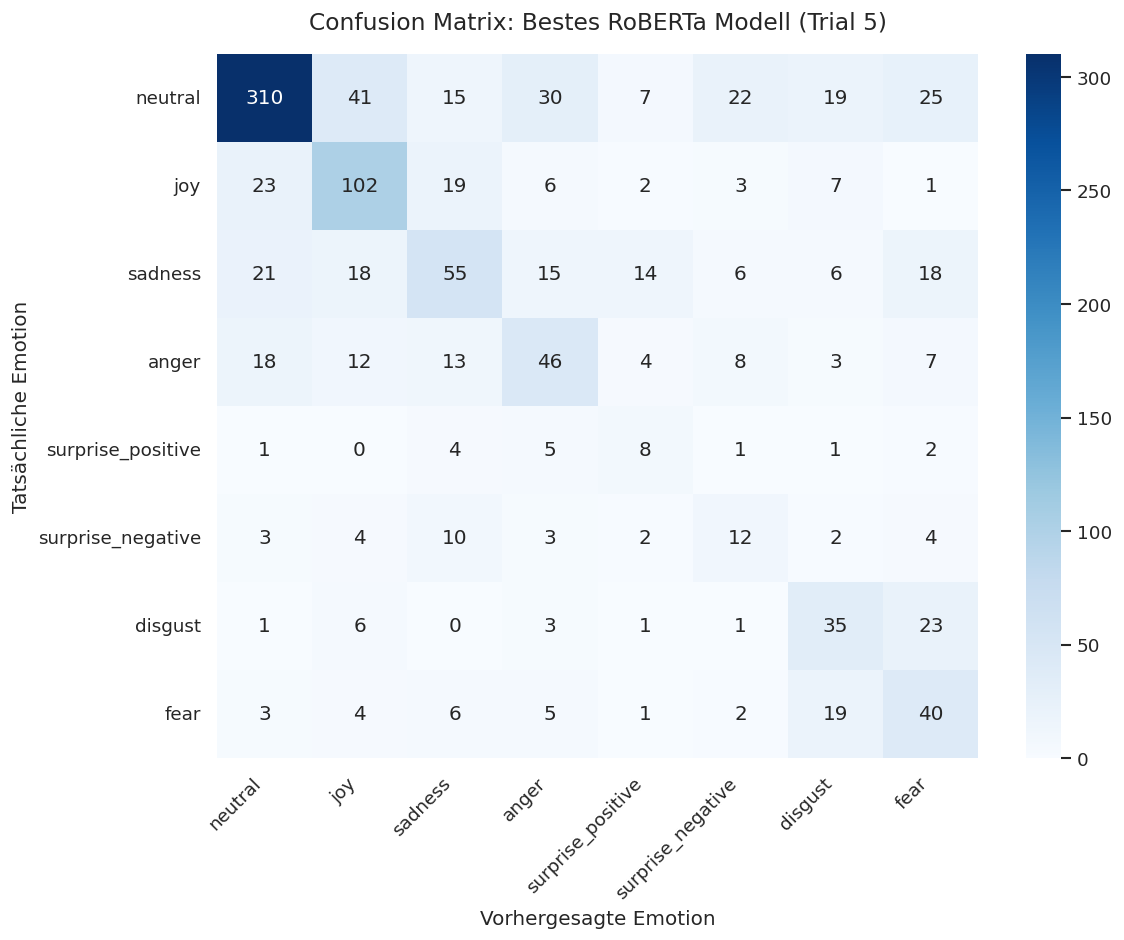

In [23]:
#confusion matrix des besten modells

import os
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from transformers import AutoModelForSequenceClassification, Trainer

# ==========================================
# 1. SETUP & MODELL LADEN (Deep Scanner)
# ==========================================
best_trial_num = "5" 
base_path = f"../data/models/optuna_trial_{best_trial_num}"

# Wir suchen jetzt aktiv nach JEDEM Ordner, der eine config.json enthält
valid_model_paths = []
for root, dirs, files in os.walk(base_path):
    if "config.json" in files:
        valid_model_paths.append(root)

if not valid_model_paths:
    raise FileNotFoundError(f"Panik! Es gibt im gesamten Ordner {base_path} keine einzige config.json. Wurde der Lauf abgebrochen?")

# Funktion, um die Checkpoint-Nummer als Zahl (nicht als Text) zu lesen
def get_checkpoint_step(path):
    basename = os.path.basename(path)
    if "checkpoint" in basename:
        try:
            return int(basename.split("-")[-1])
        except ValueError:
            return 0
    return -1 

# Wir sortieren strikt nach der Checkpoint-Nummer und nehmen den höchsten (neuesten)
valid_model_paths.sort(key=get_checkpoint_step)
best_model_path = valid_model_paths[-1]

print(f"🔎 config.json gefunden in: {best_model_path}")
print("Lade Modell in den Speicher...")

# Lade das Modell von dem exakten Pfad, wo die config liegt
best_model = AutoModelForSequenceClassification.from_pretrained(best_model_path)
inference_trainer = Trainer(model=best_model)

# ==========================================
# 2. VORHERSAGEN GENERIEREN
# ==========================================
print("Generiere Vorhersagen auf dem Val-Set...")
# dev_dataset muss aus den vorherigen Zellen noch im Speicher sein!
predictions_output = inference_trainer.predict(val_dataset)

logits = predictions_output.predictions
y_pred = np.argmax(logits, axis=1) # Die finale Entscheidung des Modells
y_true = predictions_output.label_ids # Die echten Labels

# ==========================================
# 3. CONFUSION MATRIX PLOTTEN
# ==========================================
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_true, y_pred)

# Nutze dein EMOTION_ORDER Array aus den Setup-Zellen
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=EMOTION_ORDER, yticklabels=EMOTION_ORDER)

plt.title('Confusion Matrix: Bestes RoBERTa Modell (Trial 5)', fontsize=14, pad=15)
plt.ylabel('Tatsächliche Emotion', fontsize=12)
plt.xlabel('Vorhergesagte Emotion', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.savefig("../outputs/plots/confusion_matrix_text.png", dpi=300, bbox_inches="tight")
print(f"📸 Bild gespeichert")

# Zeige den Plot im Notebook an
plt.show()